Задание 1 (2 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/stealthtechnologies/predict-the-age-of-a-fossil;
2. Построить регрессионную модель, предсказывающую возраст ископаемого с значением R-квадрат не ниже 0,8;
3. Сгенерировать 10 значений для независимых переменных и на основании полученной модели определить возраст ископаемого;

Размер: (4398, 13)

Первые 5 строк:
   uranium_lead_ratio  carbon_14_ratio  radioactive_decay_series  \
0            0.738061         0.487707                  0.907884   
1            0.560096         0.341738                  1.121302   
2            0.424773         0.218493                  0.103855   
3            0.349958         0.704649                  0.383617   
4            0.886811         0.777494                  0.593254   

   stratigraphic_layer_depth geological_period paleomagnetic_data  \
0                      91.17        Cretaceous    Normal polarity   
1                     165.44          Cambrian    Normal polarity   
2                     218.98          Cambrian    Normal polarity   
3                      51.09           Permian    Normal polarity   
4                     313.72          Devonian    Normal polarity   

   inclusion_of_other_fossils  isotopic_composition surrounding_rock_type  \
0                       False              0.915951          Co

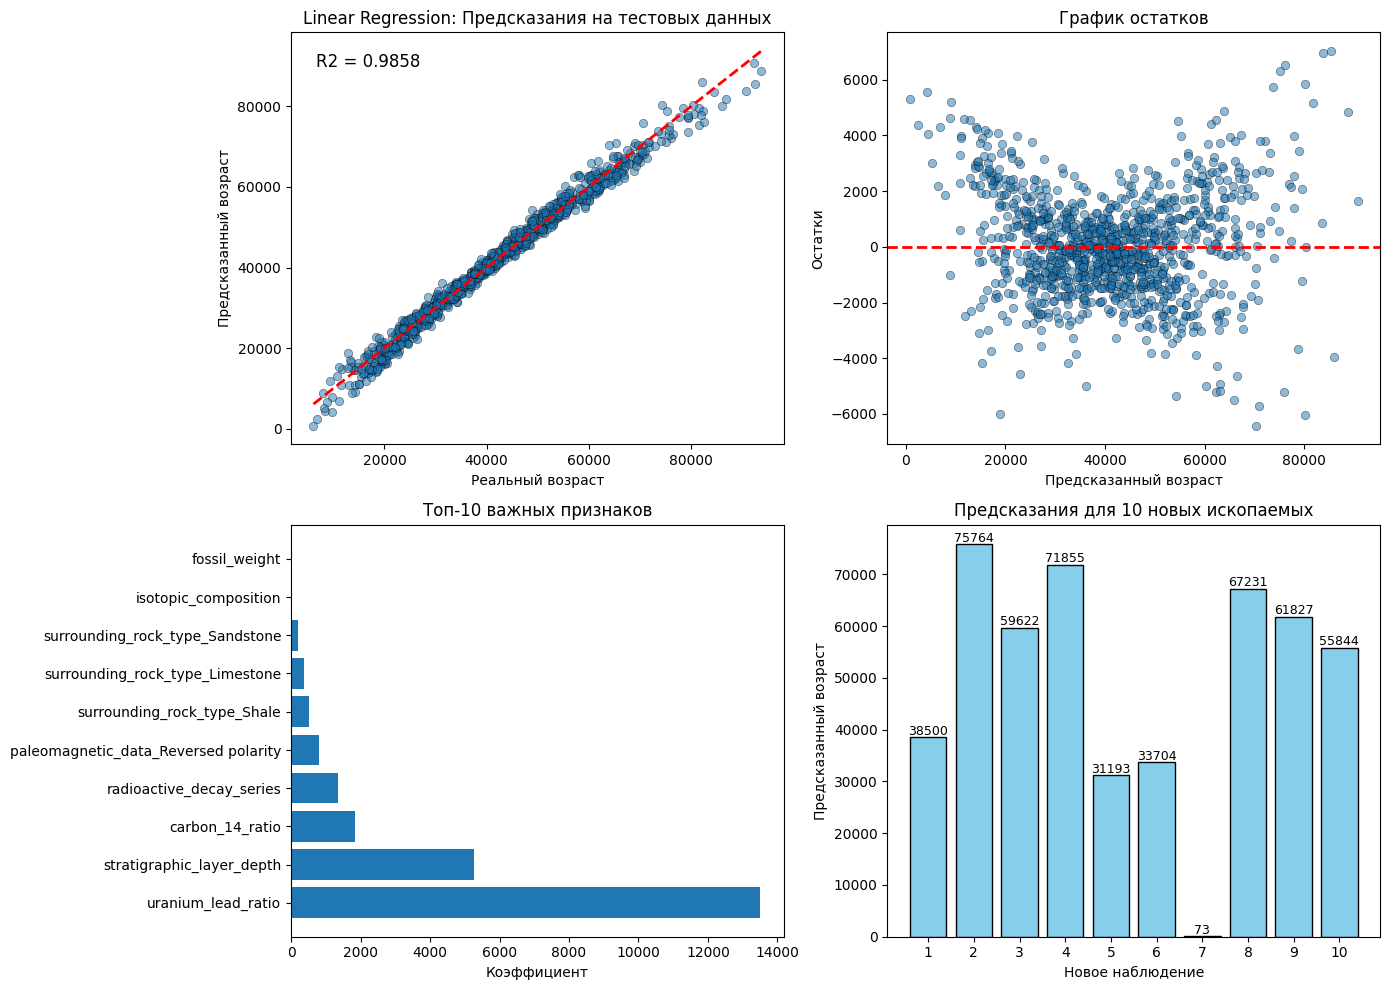

Лучшая модель: Linear Regression
R2 на тестовых данных: 0.9858
Успешно!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

train_data = pd.read_csv('train_data.csv')  
test_data = pd.read_csv('test_data.csv')  

print(f"Размер: {train_data.shape}")
print("\nПервые 5 строк:")
print(train_data.head())

print(f"Размер: {test_data.shape}")
print("\nПервые 5 строк:")
print(test_data.head())

target_col = 'age'

feature_cols = train_data.select_dtypes(include=[np.number]).columns.tolist()
if target_col in feature_cols:
    feature_cols.remove(target_col)

print(f"\nЦелевая переменная: {target_col}")
print(f"Числовые признаки ({len(feature_cols)}): {feature_cols}")

categorical_cols = train_data.select_dtypes(include=['object', 'category']).columns.tolist()
if categorical_cols:
    print(f"\nКатегориальные признаки: {categorical_cols}")
    
    for col in categorical_cols:
        train_dummies = pd.get_dummies(train_data[col], prefix=col, drop_first=True)
        test_dummies = pd.get_dummies(test_data[col], prefix=col, drop_first=True)
        
        train_data = pd.concat([train_data, train_dummies], axis=1)
        test_data = pd.concat([test_data, test_dummies], axis=1)
        
        feature_cols.extend(train_dummies.columns.tolist())

print(f"\nВсего признаков после кодирования: {len(feature_cols)}")

X_train = train_data[feature_cols]
y_train = train_data[target_col]
X_test = test_data[feature_cols]
y_test = test_data[target_col]

print(f"\nПропуски в train: {X_train.isnull().sum().sum()}")
print(f"Пропуски в test: {X_test.isnull().sum().sum()}")

if X_train.isnull().sum().sum() > 0:
    X_train = X_train.fillna(X_train.median())
if X_test.isnull().sum().sum() > 0:
    X_test = X_test.fillna(X_test.median())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Linear Regression': LinearRegression(),
    'Linear Regression (poly features)': LinearRegression(),
    'Ridge Regression': LinearRegression()
}

results = []

model1 = LinearRegression()
model1.fit(X_train_scaled, y_train)
y_pred_train1 = model1.predict(X_train_scaled)
y_pred_test1 = model1.predict(X_test_scaled)

r2_train1 = metrics.r2_score(y_train, y_pred_train1)
r2_test1 = metrics.r2_score(y_test, y_pred_test1)
rmse1 = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test1))
mae1 = metrics.mean_absolute_error(y_test, y_pred_test1)

print(f"   R2 train: {r2_train1:.4f}")
print(f"   R2 test: {r2_test1:.4f}")
print(f"   RMSE: {rmse1:.2f}")
print(f"   MAE: {mae1:.2f}")

results.append({
    'Модель': 'Linear Regression',
    'R2 train': round(r2_train1, 4),
    'R2 test': round(r2_test1, 4),
    'RMSE': round(rmse1, 2),
    'MAE': round(mae1, 2)
})

if r2_test1 < 0.8:
    print(f"\n2. Добавляем полиномиальные признаки для улучшения R2 (< 0.8)...")
    
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    selector = SelectKBest(f_regression, k=min(50, X_train_poly.shape[1]))
    X_train_selected = selector.fit_transform(X_train_poly, y_train)
    X_test_selected = selector.transform(X_test_poly)
    
    model2 = LinearRegression()
    model2.fit(X_train_selected, y_train)
    
    y_pred_train2 = model2.predict(X_train_selected)
    y_pred_test2 = model2.predict(X_test_selected)
    
    r2_train2 = metrics.r2_score(y_train, y_pred_train2)
    r2_test2 = metrics.r2_score(y_test, y_pred_test2)
    rmse2 = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test2))
    mae2 = metrics.mean_absolute_error(y_test, y_pred_test2)
    
    print(f"   R2 train: {r2_train2:.4f}")
    print(f"   R2 test: {r2_test2:.4f}")
    print(f"   RMSE: {rmse2:.2f}")
    print(f"   MAE: {mae2:.2f}")
    
    results.append({
        'Модель': 'Linear Regression (poly)',
        'R2 train': round(r2_train2, 4),
        'R2 test': round(r2_test2, 4),
        'RMSE': round(rmse2, 2),
        'MAE': round(mae2, 2)
    })

results_df = pd.DataFrame(results)
best_model_idx = results_df['R2 test'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Модель']
best_r2 = results_df.loc[best_model_idx, 'R2 test']

print(results_df.to_string(index=False))

print(f"\nЛучшая модель: {best_model_name}")
print(f"R2 на тесте: {best_r2:.4f}")

if best_r2 >= 0.8:
    print("Требование задания выполнено! R2 >= 0.8")
else:
    print(f"R2 = {best_r2:.4f} < 0.8. Требуется улучшение.")

if best_model_name == 'Linear Regression':
    best_model = model1
    X_final = X_train_scaled
else:
    best_model = model2
    X_final = X_train_selected

np.random.seed(42)
n_new = 10
new_data = pd.DataFrame()

for i, col in enumerate(feature_cols):
    min_val = train_data[col].min()
    max_val = train_data[col].max()
    new_data[col] = np.random.uniform(min_val, max_val, n_new)

print(new_data.to_string())

new_data_scaled = scaler.transform(new_data)

if best_model_name != 'Linear Regression':
    new_data_poly = poly.transform(new_data_scaled)
    new_data_final = selector.transform(new_data_poly)
else:
    new_data_final = new_data_scaled

predictions = best_model.predict(new_data_final)

for i, pred in enumerate(predictions):
    print(f"{i+1}. Возраст: {pred:.0f} лет")

new_data_with_pred = new_data.copy()
new_data_with_pred['Predicted_Age'] = predictions.astype(int)

print("\nПолная таблица с предсказаниями:")
print(new_data_with_pred.to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
if best_model_name == 'Linear Regression':
    y_pred_test_final = model1.predict(X_test_scaled)
else:
    y_pred_test_final = model2.predict(X_test_selected)

ax1.scatter(y_test, y_pred_test_final, alpha=0.5, edgecolors='black', linewidth=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Реальный возраст')
ax1.set_ylabel('Предсказанный возраст')
ax1.set_title(f'{best_model_name}: Предсказания на тестовых данных')
ax1.text(0.05, 0.95, f'R2 = {best_r2:.4f}', transform=ax1.transAxes, 
         fontsize=12, verticalalignment='top')

ax2 = axes[0, 1]
residuals = y_test - y_pred_test_final
ax2.scatter(y_pred_test_final, residuals, alpha=0.5, edgecolors='black', linewidth=0.5)
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Предсказанный возраст')
ax2.set_ylabel('Остатки')
ax2.set_title('График остатков')

ax3 = axes[1, 0]
if best_model_name == 'Linear Regression':
    coefs = model1.coef_
    coef_df = pd.DataFrame({
        'Признак': feature_cols[:len(coefs)],
        'Коэффициент': coefs
    }).sort_values('Коэффициент', ascending=False).head(10)
    
    ax3.barh(range(len(coef_df)), coef_df['Коэффициент'])
    ax3.set_yticks(range(len(coef_df)))
    ax3.set_yticklabels(coef_df['Признак'])
    ax3.set_xlabel('Коэффициент')
    ax3.set_title('Топ-10 важных признаков')

ax4 = axes[1, 1]
ax4.bar(range(1, n_new+1), predictions, color='skyblue', edgecolor='black')
ax4.set_xlabel('Новое наблюдение')
ax4.set_ylabel('Предсказанный возраст')
ax4.set_title('Предсказания для 10 новых ископаемых')
ax4.set_xticks(range(1, n_new+1))

for i, v in enumerate(predictions):
    ax4.text(i+1, v + 500, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Лучшая модель: {best_model_name}")
print(f"R2 на тестовых данных: {best_r2:.4f}")

if best_r2 >= 0.8:
    print("Успешно!")
else:
    print("R2 ниже требуемого значения 0.8")

Задание 2 (2 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/martaarroyo/palmer-penguins-for-binary-classification;
2. Построить модель логистической регрессии по столбцу species;
3. Визуализировать полученное разделение данных;

Первые 5 строк данных:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen            36.7           19.3              193.0   
4  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g  year  
0       3750.0  2007  
1       3800.0  2007  
2       3250.0  2007  
3       3450.0  2007  
4       3650.0  2007  

Распределение по видам:
species
Adelie    151
Gentoo    123
Name: count, dtype: int64

Размер после удаления пропусков: (274, 7)
Кодирование видов: {'Adelie': np.int64(0), 'Gentoo': np.int64(1)}

Метрики качества модели:
Accuracy (точность): 1.0000
Precision: 1.0000
Recall: 1.0000
F1-score: 1.0000

Матрица ошибок:
               Pred_Adelie  Pred_Gentoo
Actual_Adelie           30           

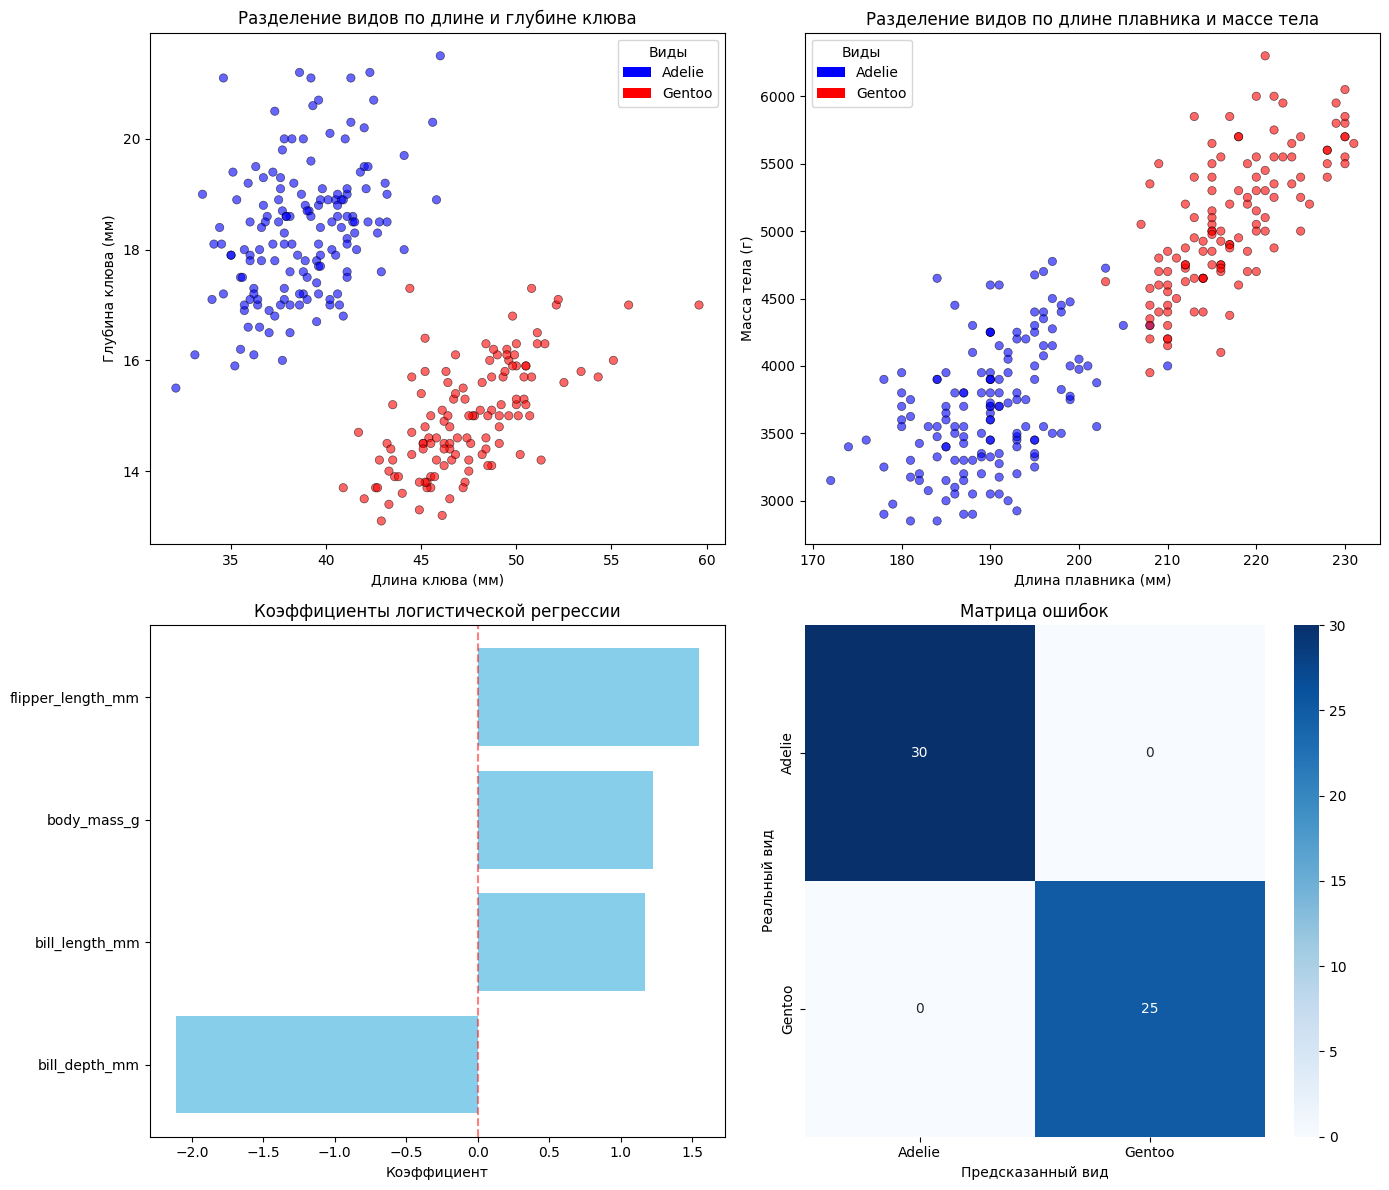

КОЭФФИЦИЕНТЫ МОДЕЛИ
Свободный член (intercept): -0.8746
bill_length_mm: 1.1669
bill_depth_mm: -2.1112
flipper_length_mm: 1.5479
body_mass_g: 1.2232
Точность: 100.0%


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics

df_penguins = pd.read_csv('penguins_binary_classification.csv')
print("Первые 5 строк данных:")
print(df_penguins.head())
print("\nРаспределение по видам:")
print(df_penguins['species'].value_counts())

df_penguins = df_penguins.dropna()
print(f"\nРазмер после удаления пропусков: {df_penguins.shape}")

le = LabelEncoder()
df_penguins['species_encoded'] = le.fit_transform(df_penguins['species'])
species_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Кодирование видов: {species_mapping}")

feature_cols_penguins = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_peng = df_penguins[feature_cols_penguins]
y_peng = df_penguins['species_encoded']

scaler = StandardScaler()
X_peng_scaled = scaler.fit_transform(X_peng)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_peng_scaled, y_peng, test_size=0.2, random_state=42, stratify=y_peng
)

model_peng = LogisticRegression(max_iter=1000)
model_peng.fit(X_train_p, y_train_p)

y_pred_peng = model_peng.predict(X_test_p)
y_pred_proba = model_peng.predict_proba(X_test_p)

accuracy = metrics.accuracy_score(y_test_p, y_pred_peng)
precision = metrics.precision_score(y_test_p, y_pred_peng)
recall = metrics.recall_score(y_test_p, y_pred_peng)
f1 = metrics.f1_score(y_test_p, y_pred_peng)

print(f"\nМетрики качества модели:")
print(f"Accuracy (точность): {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

cm = metrics.confusion_matrix(y_test_p, y_pred_peng)
cm_df = pd.DataFrame(cm, 
                     columns=[f'Pred_{cls}' for cls in le.classes_],
                     index=[f'Actual_{cls}' for cls in le.classes_])
print("\nМатрица ошибок:")
print(cm_df)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax1 = axes[0, 0]
colors = ['blue' if x == 0 else 'red' for x in df_penguins['species_encoded']]
ax1.scatter(df_penguins['bill_length_mm'], df_penguins['bill_depth_mm'], 
           c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Длина клюва (мм)')
ax1.set_ylabel('Глубина клюва (мм)')
ax1.set_title('Разделение видов по длине и глубине клюва')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Adelie'),
                  Patch(facecolor='red', label='Gentoo')]
ax1.legend(handles=legend_elements, title="Виды")

ax2 = axes[0, 1]
ax2.scatter(df_penguins['flipper_length_mm'], df_penguins['body_mass_g'], 
           c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Длина плавника (мм)')
ax2.set_ylabel('Масса тела (г)')
ax2.set_title('Разделение видов по длине плавника и массе тела')
ax2.legend(handles=legend_elements, title="Виды")

ax3 = axes[1, 0]
coef_df = pd.DataFrame({
    'Признак': feature_cols_penguins,
    'Коэффициент': model_peng.coef_[0]
})
coef_df = coef_df.sort_values('Коэффициент', ascending=True)
ax3.barh(coef_df['Признак'], coef_df['Коэффициент'], color='skyblue')
ax3.set_xlabel('Коэффициент')
ax3.set_title('Коэффициенты логистической регрессии')
ax3.axvline(x=0, color='red', linestyle='--', alpha=0.5)

ax4 = axes[1, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax4.set_xlabel('Предсказанный вид')
ax4.set_ylabel('Реальный вид')
ax4.set_title('Матрица ошибок')

plt.tight_layout()
plt.show()

print("КОЭФФИЦИЕНТЫ МОДЕЛИ")
print(f"Свободный член (intercept): {model_peng.intercept_[0]:.4f}")
for i, col in enumerate(feature_cols_penguins):
    print(f"{col}: {model_peng.coef_[0][i]:.4f}")

print(f"Точность: {accuracy*100:.1f}%")

Задание* (4 балла)
1. Скачать данные по ссылке https://www.kaggle.com/datasets/yasserh/song-popularity-dataset
2. Проверить данные на мультиколлинеарность: вывести матрицу корреляции и рассчитать VIF;
3. Построить регрессионные модели с зависимой переменной song_popularity (например, можно взять следующие модели: множественная линейная регрессия, ридж-регрессия, случайный лес. Подробнее: https://scikit-learn.org/stable/);
4. Сравнить метрики качества регрессионных моделей, выбрать лучшую, сделать выводы.


Размер датасета: (18835, 15)
Колонки: ['song_name', 'song_popularity', 'song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'audio_mode', 'speechiness', 'tempo', 'time_signature', 'audio_valence']

Используем 13 признаков: ['song_duration_ms', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'audio_mode', 'speechiness', 'tempo', 'time_signature', 'audio_valence']

Пропущенные значения: 0
МАТРИЦА КОРРЕЛЯЦИИ
Корреляция между признаками (первые 5x5):
                  song_duration_ms  acousticness  danceability  energy  \
song_duration_ms              1.00         -0.10         -0.10    0.09   
acousticness                 -0.10          1.00         -0.18   -0.66   
danceability                 -0.10         -0.18          1.00    0.04   
energy                        0.09         -0.66          0.04    1.00   
instrumentalness             -0.02          0.17         -0.13   -0.21   


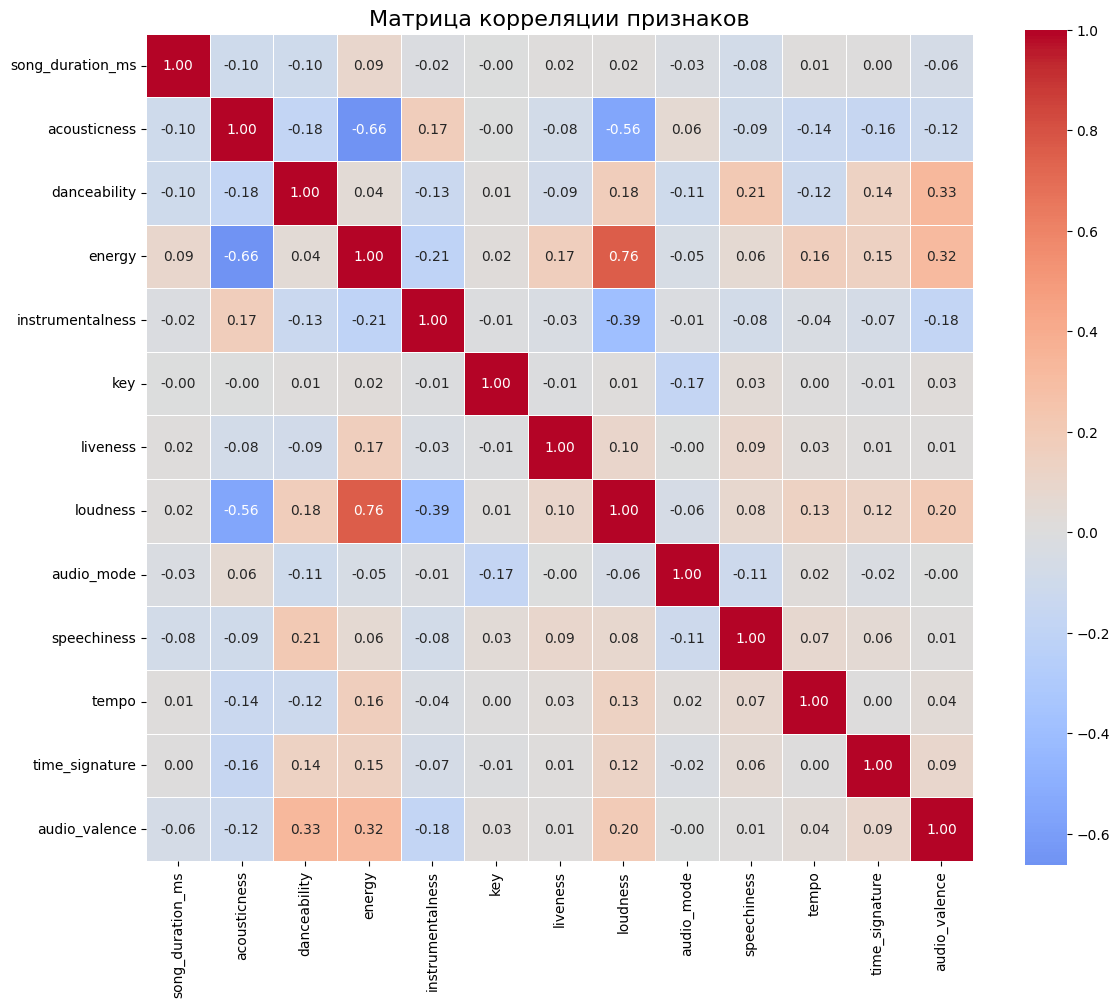


Пары признаков с высокой корреляцией (|r| > 0.7):
energy — loudness: 0.756

VIF для признаков (VIF > 10 указывает на мультиколлинеарность):
         Признак  VIF
song_duration_ms 1.05
    acousticness 1.98
    danceability 1.43
          energy 3.73
instrumentalness 1.25
             key 1.03
        liveness 1.05
        loudness 2.94
      audio_mode 1.06
     speechiness 1.10
           tempo 1.06
  time_signature 1.05
   audio_valence 1.39

Все признаки имеют VIF <= 10. Серьезной мультиколлинеарности не обнаружено.


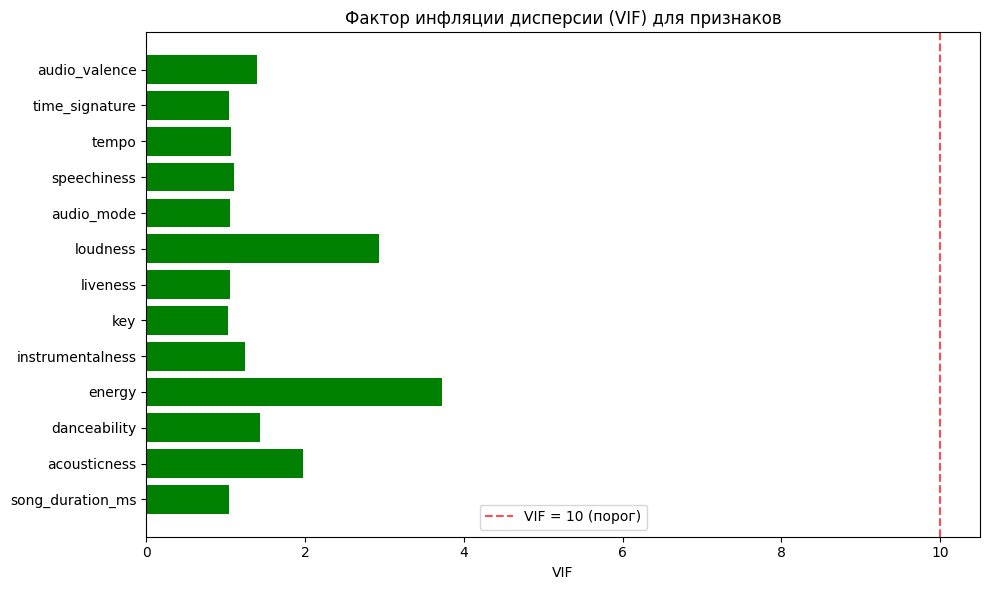


Обучение Linear Regression...
  R2 train: 0.047, R2 test: 0.042
  RMSE: 21.49, MAE: 17.06
  CV R2: 0.019 (+/- 0.056)

Обучение Ridge Regression...
  R2 train: 0.047, R2 test: 0.042
  RMSE: 21.49, MAE: 17.06
  CV R2: 0.019 (+/- 0.056)

Обучение Random Forest...
  R2 train: 0.439, R2 test: 0.226
  RMSE: 19.32, MAE: 15.24
  CV R2: 0.178 (+/- 0.085)
           Модель  R2 train  R2 test  RMSE   MAE  CV R2
    Random Forest     0.439    0.226 19.32 15.24  0.178
Linear Regression     0.047    0.042 21.49 17.06  0.019
 Ridge Regression     0.047    0.042 21.49 17.06  0.019


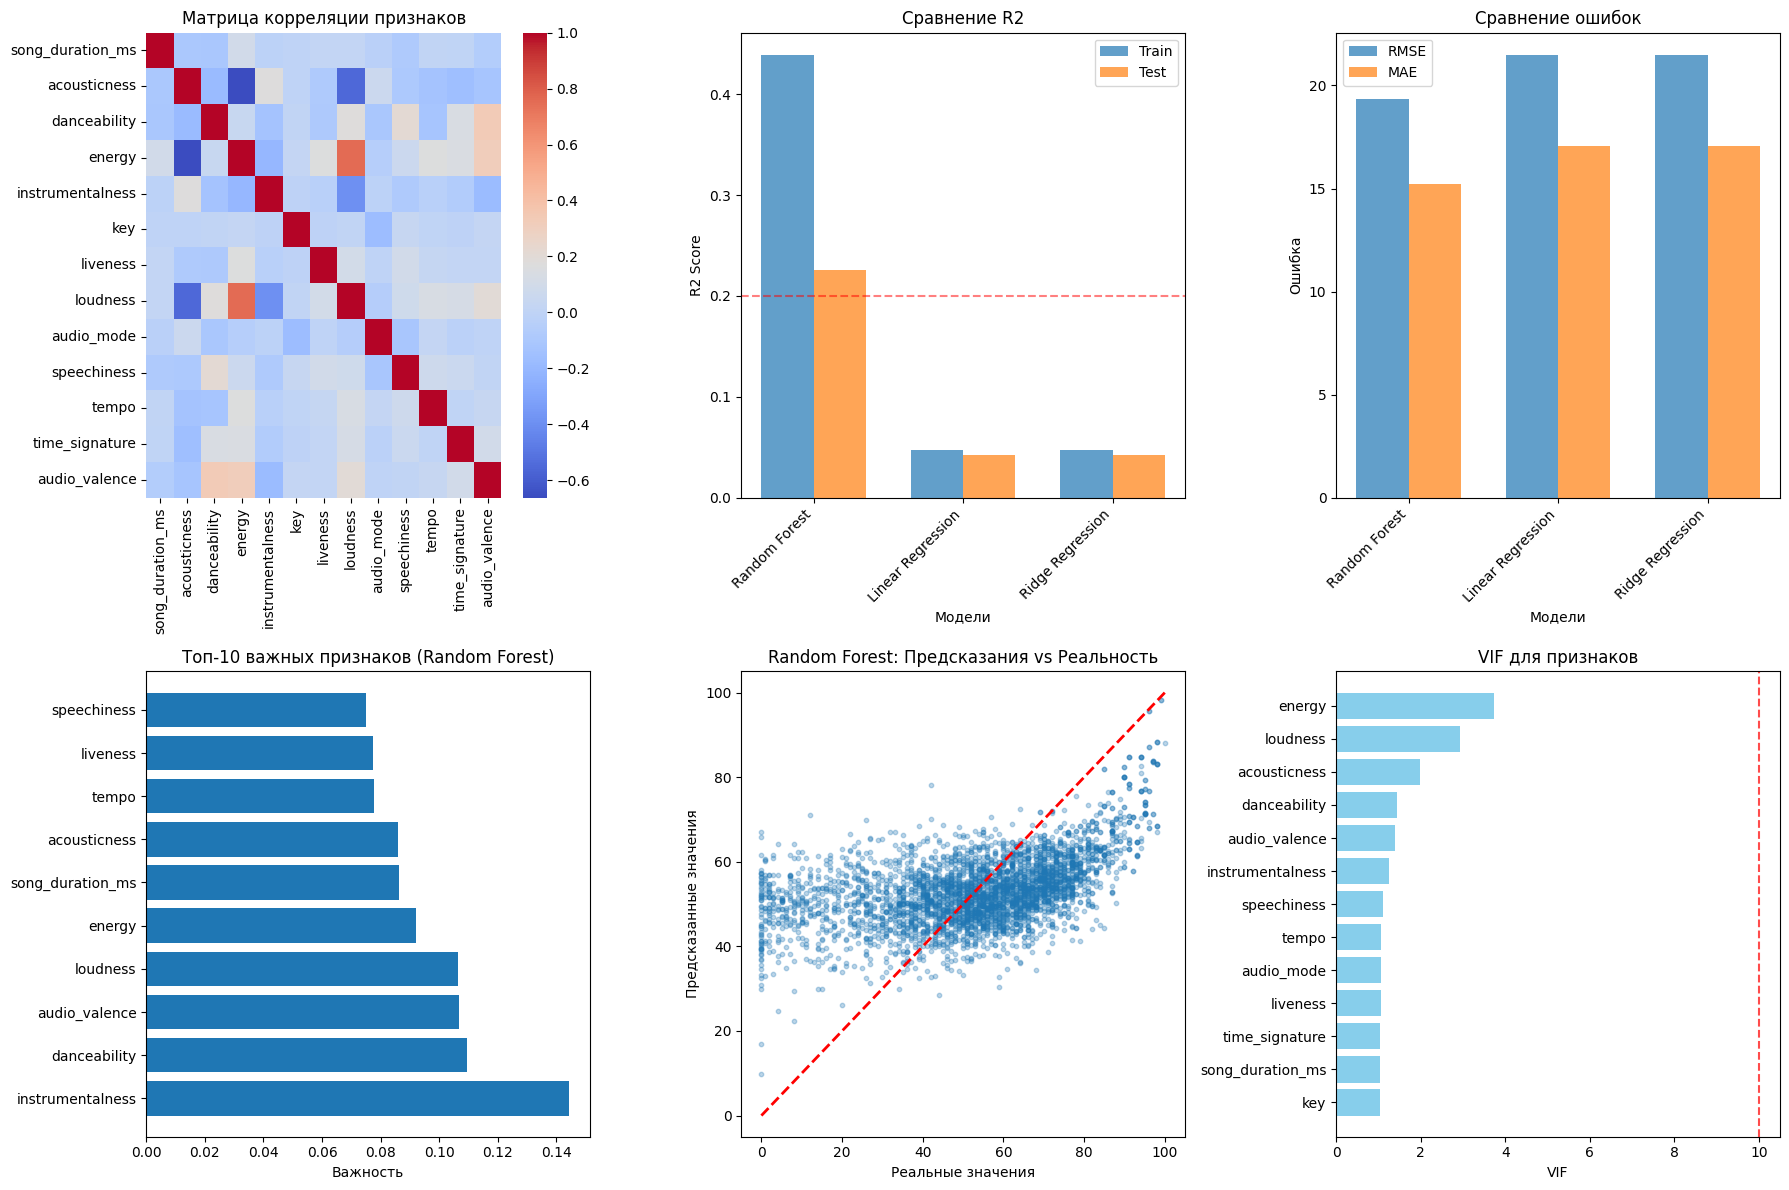


Лучшая модель: Random Forest
R2 на тесте: 0.226
RMSE: 19.32
MAE: 15.24

Анализ мультиколлинеарности:
Все признаки имеют VIF <= 10, серьезной мультиколлинеарности не обнаружено.

Анализ результатов моделирования:
Модель показывает низкое качество (R2 < 0.3)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

df_songs = pd.read_csv('song_data.csv')
print(f"Размер датасета: {df_songs.shape}")
print(f"Колонки: {df_songs.columns.tolist()}")

target = 'song_popularity'
feature_cols = df_songs.select_dtypes(include=[np.number]).columns.tolist()
feature_cols.remove(target) 

print(f"\nИспользуем {len(feature_cols)} признаков: {feature_cols}")

X = df_songs[feature_cols].copy() 
y = df_songs[target].copy()

print(f"\nПропущенные значения: {X.isnull().sum().sum()}")

print("МАТРИЦА КОРРЕЛЯЦИИ")
corr_matrix = X.corr()

print("Корреляция между признаками (первые 5x5):")
print(corr_matrix.iloc[:5, :5].round(2))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляции признаков', fontsize=16)
plt.tight_layout()
plt.show()

high_corr = []
print("\nПары признаков с высокой корреляцией (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': round(corr_matrix.iloc[i, j], 3)
            })
            print(f"{corr_matrix.columns[i]} — {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

if not high_corr:
    print("Сильных корреляций не обнаружено (|r| <= 0.7)")

X_with_const = add_constant(X)

vif_data = pd.DataFrame()
vif_data["Признак"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                   for i in range(X_with_const.shape[1])]

vif_data = vif_data[vif_data["Признак"] != "const"]

print("\nVIF для признаков (VIF > 10 указывает на мультиколлинеарность):")
print(vif_data.round(2).to_string(index=False))

high_vif = vif_data[vif_data["VIF"] > 10]
if not high_vif.empty:
    print("\nПроблемные признаки (VIF > 10):")
    print(high_vif.round(2).to_string(index=False))
    
    print("\nРекомендация: рассмотреть возможность удаления или комбинирования этих признаков.")
else:
    print("\nВсе признаки имеют VIF <= 10. Серьезной мультиколлинеарности не обнаружено.")

# Визуализация VIF
plt.figure(figsize=(10, 6))
colors = ['red' if vif > 10 else 'green' for vif in vif_data['VIF']]
plt.barh(vif_data['Признак'], vif_data['VIF'], color=colors)
plt.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='VIF = 10 (порог)')
plt.xlabel('VIF')
plt.title('Фактор инфляции дисперсии (VIF) для признаков')
plt.legend()
plt.tight_layout()
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    print(f"\nОбучение {name}...")
    
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Метрики
    r2_train = metrics.r2_score(y_train, y_pred_train)
    r2_test = metrics.r2_score(y_test, y_pred_test)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred_test))
    mae = metrics.mean_absolute_error(y_test, y_pred_test)
    
    cv_scores = cross_val_score(model, X_scaled, y, cv=3, scoring='r2')
    
    results.append({
        'Модель': name,
        'R2 train': round(r2_train, 3),
        'R2 test': round(r2_test, 3),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'CV R2': round(cv_scores.mean(), 3)
    })
    
    print(f"  R2 train: {r2_train:.3f}, R2 test: {r2_test:.3f}")
    print(f"  RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    print(f"  CV R2: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2 test', ascending=False)

print(results_df.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ax1 = axes[0, 0]
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', ax=ax1, cbar=True)
ax1.set_title('Матрица корреляции признаков')

ax2 = axes[0, 1]
x = np.arange(len(results_df))
width = 0.35
ax2.bar(x - width/2, results_df['R2 train'], width, label='Train', alpha=0.7)
ax2.bar(x + width/2, results_df['R2 test'], width, label='Test', alpha=0.7)
ax2.set_xlabel('Модели')
ax2.set_ylabel('R2 Score')
ax2.set_title('Сравнение R2')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Модель'], rotation=45, ha='right')
ax2.legend()
ax2.axhline(y=0.2, color='r', linestyle='--', alpha=0.5, label='R2=0.2')

ax3 = axes[0, 2]
ax3.bar(x - width/2, results_df['RMSE'], width, label='RMSE', alpha=0.7)
ax3.bar(x + width/2, results_df['MAE'], width, label='MAE', alpha=0.7)
ax3.set_xlabel('Модели')
ax3.set_ylabel('Ошибка')
ax3.set_title('Сравнение ошибок')
ax3.set_xticks(x)
ax3.set_xticklabels(results_df['Модель'], rotation=45, ha='right')
ax3.legend()

ax4 = axes[1, 0]
if 'Random Forest' in models:
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    feat_imp = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=False).head(10)
    
    ax4.barh(feat_imp['feature'], feat_imp['importance'])
    ax4.set_xlabel('Важность')
    ax4.set_title('Топ-10 важных признаков (Random Forest)')

ax5 = axes[1, 1]
best_model_name = results_df.iloc[0]['Модель']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
ax5.scatter(y_test, y_pred_best, alpha=0.3, s=10)
ax5.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax5.set_xlabel('Реальные значения')
ax5.set_ylabel('Предсказанные значения')
ax5.set_title(f'{best_model_name}: Предсказания vs Реальность')

ax6 = axes[1, 2]
vif_sorted = vif_data.sort_values('VIF', ascending=True)
colors_vif = ['red' if v > 10 else 'skyblue' for v in vif_sorted['VIF']]
ax6.barh(vif_sorted['Признак'], vif_sorted['VIF'], color=colors_vif)
ax6.axvline(x=10, color='red', linestyle='--', alpha=0.7)
ax6.set_xlabel('VIF')
ax6.set_title('VIF для признаков')

plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print(f"\nЛучшая модель: {best_model['Модель']}")
print(f"R2 на тесте: {best_model['R2 test']}")
print(f"RMSE: {best_model['RMSE']}")
print(f"MAE: {best_model['MAE']}")

print("\nАнализ мультиколлинеарности:")
if not high_vif.empty:
    print(f"Обнаружены признаки с VIF > 10, что указывает на мультиколлинеарность.")
    for _, row in high_vif.iterrows():
        print(f"  - {row['Признак']}: VIF = {row['VIF']:.2f}")
else:
    print("Все признаки имеют VIF <= 10, серьезной мультиколлинеарности не обнаружено.")

print("\nАнализ результатов моделирования:")
if best_model['R2 test'] < 0.3:
    print("Модель показывает низкое качество (R2 < 0.3)")
else:
    print("Модель показывает приемлемое качество")